Welcome to the EPISOL Colab Playground!



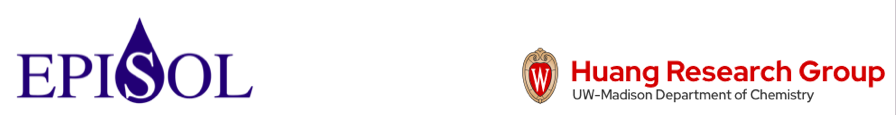

The 3D reference interaction site model (3DRISM) provides an efficient grid-based solvation model to compute the structural and thermodynamic properties of solutes emersed in solvent. However, this solvent need not be aqueous, and can hypothetically be *any* molecule. In this notebook we will walk through a high-throughput calculation on the solvation free energy of a test set of small molecules, emersed in an organic solvent.  

* **goals**:
  * generate correlations for an organic solvent using 1DRISM
  * Generate the coordinate and topology files for our test set using RDKit and openFF
  * Perform high-throughput 3DRISM calculations to determine solvation free energy of 100 electrolyte molecules in the test set
  * Be able to perform similar calculations on your own molecules
    * use the colab-notebook to download and run calculations on your own molecules

In [2]:
#@title ##Download and Install Episol
#@markdown ($\approx 2$min) Stable as of 07/01/25 eprism v1.2.6
%%capture
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
#%cd ../home/
%cd $HOME/
%mkdir episol
%cd episol
!wget https://github.com/EPISOLrelease/EPISOL/raw/refs/heads/main/src/fftw/fftw-3.3.8.tar.gz
!echo "+++++++++++++++++++"
!echo "downloaded fftw files"
!echo "+++++++++++++++++++"
!tar -xzf fftw-3.3.8.tar.gz
%cd fftw-3.3.8/
#!./configure --prefix=/home/fftw-3.3.8
!./configure --prefix=$HOME/episol/fftw-3.3.8
!make
!make install
%cd ../
!wget https://github.com/EPISOLrelease/EPISOL/raw/refs/heads/main/src/kernel/release.tar.gz
!echo "+++++++++++++++++++"
!echo "downloaded Episol files"
!echo "+++++++++++++++++++"
!tar -xzf release.tar.gz
%cd release/
#!./configure --with-fftw=/home/fftw-3.3.8
!./configure --with-fftw=$HOME/episol/fftw-3.3.8
!make
!make install
#%cd /content
########################### WRAPEPR
import subprocess
import os
import threading
import pandas as pd
import matplotlib.pyplot as plt
!pip install episol


In [3]:
#@title Install some python packages for topology generation
#@markdown ($\approx$10sec)

#@markdown This will prompt a restart in our colab session, this is necessary, just keep moving

#@markdown (if you are using the notebook offline this wont be necessary, as presumably you'll have your own forcefield to generate topologies)
########################################
#        FOR COLAB USERS ONLY          #
#---------------------------------------#
# if you are running locally you dont need
# condacolab. Just use your local conda dist
########################################
!pip install -q condacolab
import condacolab
condacolab.install()
########################################
#!conda update conda
#!conda install --yes -c conda-forge  python=3.11 numpy=1.26.4 openmm pdbfixer parmed mdanalysis py3dmol rdkit openff-toolkit
#!conda install -y -c conda-forge numpy=1.26.4 openmm=8.3.1 python={PYTHON_VERSION} pdbfixer=1.11 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 libgcc
#!conda install -y -c conda-forge python=3.12 numpy=1.26.4 openmm=8.3.1 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 torchvision
#openmm pdbfixer parmed mdanalysis py3dmol rdkitconda install libgcc

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:15
🔁 Restarting kernel...


In [4]:
%%capture
!python -m ensurepip --upgrade
!python3.12 -m pip install --upgrade setuptools
#!pip3 install scikit-learn
!conda install -y -c conda-forge python=3.12 numpy=1.26.4 openmm=8.3.1 pdbfixer=1.11 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 torchvision pymol-open-source #ambertools

In [1]:
#@title import our download packages
%%capture
import py3Dmol

def MolTo3DView(mol, size=(300, 300), style="stick", surface=False, opacity=0.5):
    """
    https://birdlet.github.io/2019/10/02/py3dmol_example/
    Draw molecule in 3D

    Args:
    ----
        mol: rdMol, molecule to show
        size: tuple(int, int), canvas size
        style: str, type of drawing molecule
               style can be 'line', 'stick', 'sphere', 'carton'
        surface, bool, display SAS
        opacity, float, opacity of surface, range 0.0-1.0
    Return:
    ----
        viewer: py3Dmol.view, a class for constructing embedded 3Dmol.js views in ipython notebooks.
    """
    assert style in ('line', 'stick', 'sphere', 'carton')
    mblock = Chem.MolToMolBlock(mol)
    viewer = py3Dmol.view(width=size[0], height=size[1])
    viewer.addModel(mblock, 'mol')
    viewer.setStyle({style:{}})
    if surface:
        viewer.addSurface(py3Dmol.SAS, {'opacity': opacity})
    viewer.zoomTo()
    return viewer
def smi2conf(smiles):
    '''Convert SMILES to rdkit.Mol with 3D coordinates'''
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        AllChem.MMFFOptimizeMolecule(mol, maxIters=200)
        return mol
    else:
        return None
#free_energy("EXP")
!python -m ensurepip --upgrade # since we are using python 3.12 some pkg utils are now obsolete
# after conda-initiate restart colab resets pip
import matplotlib.pyplot as plt
import openmm as mm
from   openmm import app
from   openmm.unit import *
import py3Dmol as pymol
import MDAnalysis as md
import parmed as chem
from openff.toolkit.topology import Molecule, Topology
import numpy as np
from MDAnalysis.transformations import center_in_box
# from episol import epipy
from rdkit import Chem
from rdkit.Chem import AllChem
from openff.toolkit.topology import Molecule
from openff.toolkit.utils import get_data_file_path
from openff.toolkit.typing.engines.smirnoff import ForceField
from openff.interchange import Interchange
##########################################
plt.rcParams.update({'font.size': 15})
plt.rcParams.update({'axes.linewidth':3})
plt.rcParams['image.cmap'] = 'turbo'
##########################################
# FIX IMPORTER ERROR
!python -m ensurepip --upgrade
!uv pip3 install episol
!python3.12 -m pip install --upgrade setuptools
%cd /content/

# Getting Started

To determine solvation density and thermodynamics, we must solve the 3DRISM equation


$$$$
$$h(r)_i^{\rm sol.-solv.} = \rho\sum_j\int c(r)_j^{\rm sol.-solv.}\chi^{\rm solv.-solv.}d\mathbf{r}$$

Using a closure relation


$$$$
$$
h(r)_i^{\rm sol.-solv.} \equiv \exp{\left( - U(r)_i^{\rm sol.-solv.} + h(r)_i^{\rm sol.-solv.}+ c(r)_i^{\rm sol.-solv.} + \mathfrak{B}\right)}
$$

$$$$

Given that we have two unknowns $h$ and $c$ we must solve in an iterative self-consisten manner. however, upon closer inspection, we have a third unkown, $\chi$, our solvent solvent susceptability. This contains our bulk solvent correlations. We need these values from MD (costly, but accurate) or from 1DRISM which is cheap, and accurate if our molecule is small and rigid (water, CO$_2$, etc.)

Previously we have used water or ions as solvent, but there is no reason why we can't use a non-aqueous  solvent. The calculation that follows is identical, however, we first need $\chi$.

Again, solvent-solvent correlations can be acquired with MD or with 1DRISM.
Here, we will use 1DRISM  to generate correlations. Then, feed these into epipy. lets start with an example solvent: Carbon Dioxide

CO$_2$  is a nice example, as it is generally easier to converge if
  * Small number of sites
  * Low dielectric constant
  * uncharged
  * high temp

* we have previously prepared proper calculations and input files, lets download them

In [146]:
!wget https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/organic/co2.gvv
!wget https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/organic/co2.sol

--2026-05-12 19:26:25--  https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/organic/co2.gvv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1982792 (1.9M) [text/plain]
Saving to: ‘co2.gvv’

co2.gvv             100%[===================>]   1.89M  --.-KB/s    in 0.04s   

2026-05-12 19:26:26 (49.6 MB/s) - ‘co2.gvv’ saved [1982792/1982792]

--2026-05-12 19:26:26--  https://raw.githubusercontent.com/p-swanson/solvents/refs/heads/main/organic/co2.sol
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 612 [text/plain]
Sav

# CO2

In [38]:
from episol import epipy

All Checks complete
Good to go!


* Co2 is commonly used for caffiene extraction
* lets see our solvent distribution around a caffiene molecule

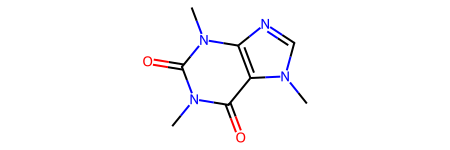

In [141]:
smi = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C" # caffiene
mol = Chem.MolFromSmiles(smi)
mol


* add hydrogens and optimize our caffiene

In [142]:
mol = Chem.rdmolops.AddHs(mol,addCoords=True)
AllChem.EmbedMolecule(mol)
AllChem.UFFOptimizeMolecule(mol)
MolTo3DView(mol).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

* now, lets write out this fixed caffiene

In [148]:
%%capture
OUTNAME="caffiene"
tmp_u = md.Universe(mol)
coords = tmp_u.atoms.positions

buffer = 10  # convert to A
#
box_x = np.ceil(np.abs(np.max((coords[:,0]))-np.min((coords[:,0])))+buffer)
box_y = np.ceil(np.abs(np.max((coords[:,1]))-np.min((coords[:,1])))+buffer)
box_z = np.ceil(np.abs(np.max((coords[:,2]))-np.min((coords[:,2])))+buffer)
tmp_u.dimensions = [box_x,box_y,box_z,90,90,90]
trans = center_in_box(tmp_u.atoms,center='geometry')

tmp_u.trajectory.add_transformations(trans)
tmp_u.atoms.write(f'{OUTNAME}.pdb')
tmp_u.atoms.write(f'{OUTNAME}.gro')
# CREATE TOP
from_rdmol = Molecule.from_rdkit(mol,allow_undefined_stereo=True)
topology = from_rdmol.to_topology()
# we will use openFF to assign SMIRNOFF parameters
sage = ForceField("openff-2.0.0.offxml")
interchange = Interchange.from_smirnoff(force_field=sage, topology=topology)
# just pick the first conformer
interchange.positions = from_rdmol.conformers[0]
#openmm_system = interchange.to_gromacs('out')
openmm_system = interchange.to_openmm()
#os.remove("out.top")
interchange.to_top(f"{OUTNAME}.top")
t = chem.load_file(f"{OUTNAME}.top")
t.positions = tmp_u.atoms.positions
t.save(f"{OUTNAME}.parm7",overwrite=True)
t.save(f"{OUTNAME}.rst7",overwrite=True)

In [149]:
# WITH EPIPY
ec = epipy("caffiene.gro","caffiene.top",gen_idc=True)
ec.closure = "KH"
ec.err_tol = 1e-12
ec.ndiis = 15
# OLD WORKS: ec.solvent("out_1.sol")
#ec.solvent("load_top_test.sol")
ec.solvent("co2.sol")
ec.solvent_path = "./"
ec.report(f"caffiene_{ec.closure}")
ec.rism(step=2000,resolution=0.25)
ec.kernel(nt=10)

converted caffiene.top to caffiene.solute
generated idc-enabled solute file to: idc_caffiene.solute
Calculation finished in 332 steps 
err_tol: 1e-12 actual: 8.81632e-13 


* now, lets extract our distribution

In [158]:
t = ec.reader("guv_caffiene_KH.txt",atom_to_select=3)
t.shape

(72, 68, 52)

In [150]:
guv = ec.select_grid()

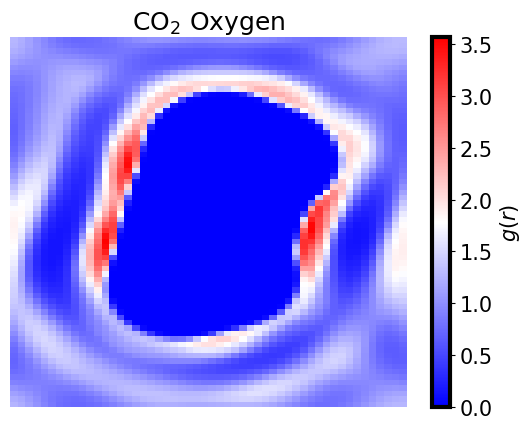

In [151]:
SLICE = 30
#C = gridData.Grid("g.C0.1.dx")
#O1 = gridData.Grid("g.O1.1.dx")
#O2 = gridData.Grid("g.O2.1.dx")
fig,axs = plt.subplots()#1,2,figsize=(10,5))
p = axs.pcolormesh(guv[SLICE],cmap='bwr')
fig.colorbar(p,ax=axs,label="$g(r)$")
axs.set_title("CO$_2$ Oxygen")

axs.set_axis_off()


* we can also select the density of each atom site.
* since water is the default solvent, our selection names wont work here, so we need to pass the atom site we wish to use, here the 2nd site is carbon

In [161]:
# extract the guv file and select our column
t = ec.reader("guv_caffiene_KH.txt",atom_to_select=-1)
t.shape

(72, 68, 52)

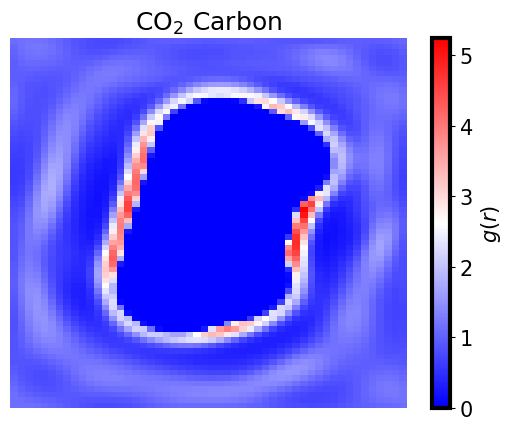

In [163]:
SLICE = 30
#C = gridData.Grid("g.C0.1.dx")
#O1 = gridData.Grid("g.O1.1.dx")
#O2 = gridData.Grid("g.O2.1.dx")
fig,axs = plt.subplots()#1,2,figsize=(10,5))
p = axs.pcolormesh(t[SLICE],cmap='bwr')
fig.colorbar(p,ax=axs,label="$g(r)$")
axs.set_title("CO$_2$ Carbon")

axs.set_axis_off()